[Taichi] Starting on arch=cuda


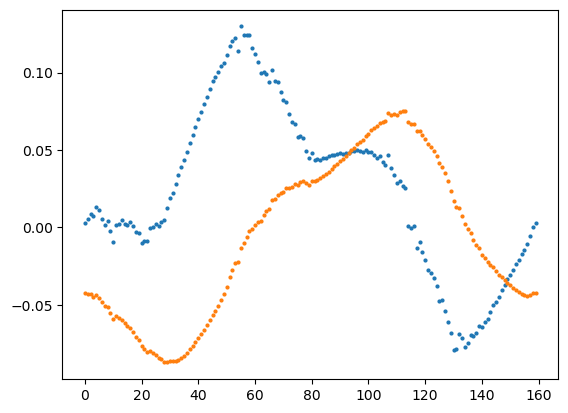

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
from utils import get_sofa
from PIL import Image

ti.init(arch=ti.gpu)

path, file_name = '../trajectory/能让鸡块旋转一周的房间_2/', 'sofa_600.npy'

# 载入轨迹数据
xs, ys, rotations = np.load(path + file_name)

# 数据点
plt.plot(xs, 'o', markersize=2)
plt.plot(ys, 'o', markersize=2)
# plt.plot(rotations, 'o', markersize=2)

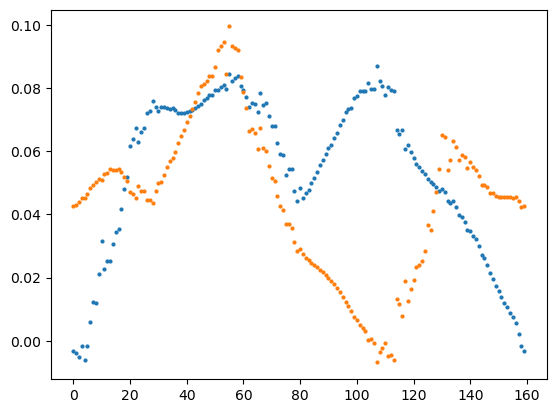

In [16]:
xs_inv = []
ys_inv = []
rotations_inv = -rotations
for x, y, angle in zip(-xs, -ys, rotations_inv):
    rotation_matrix = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    x_inv, y_inv = rotation_matrix @ np.array([x, y])
    xs_inv.append(x_inv)
    ys_inv.append(y_inv)
xs_inv = np.array(xs_inv)
ys_inv = np.array(ys_inv)

plt.plot(xs_inv, 'o', markersize=2)
plt.plot(ys_inv, 'o', markersize=2)

In [17]:
def key_function(xs, ys, rotations):  # 要求这个函数单调递增来重新采样
    return np.arange(len(xs))  # 不重新排序

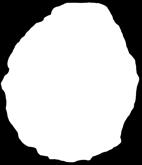

In [18]:
wall_image = Image.open('../input_images/鸡块高清蒙版.png')

wall_numpy = np.array(wall_image).T > 0  # 读取图片并转换为布尔数组
assert len(wall_numpy.shape) == 2, "Image must be grayscale"

wall_taichi = ti.field(dtype=ti.i8, shape=wall_numpy.shape)
wall_taichi.from_numpy(wall_numpy.astype(np.int8))

wall_image_down_sampled = wall_image.convert('1').convert('RGB').resize((wall_image.width // 8, wall_image.height // 8))
wall_image_down_sampled

Area = 0.7711519999999998


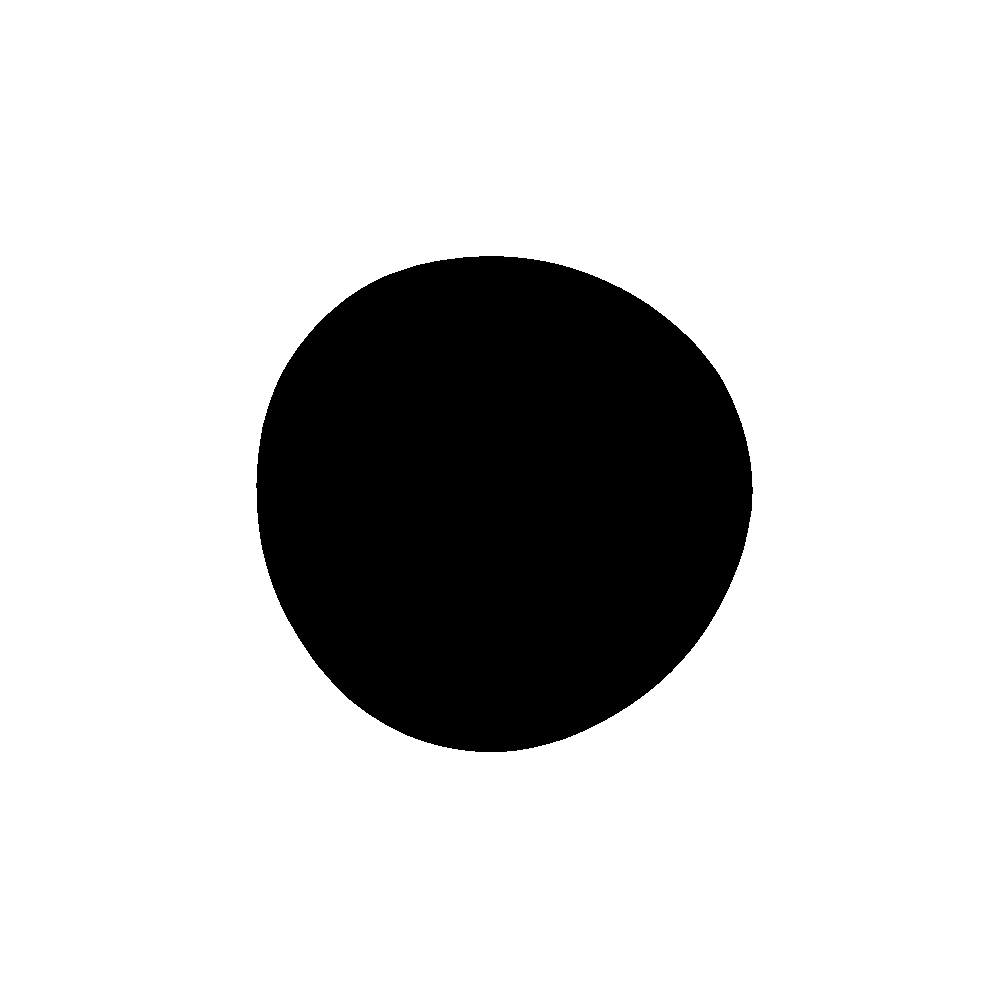

In [19]:
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    return wall_taichi[
        max(0, min(wall_taichi.shape[0] - 1, int((x2 + 0.5) * wall_taichi.shape[1] - (wall_taichi.shape[1] - wall_taichi.shape[0]) / 2))),
        max(0, min(wall_taichi.shape[1] - 1, int((y2 + 0.5) * wall_taichi.shape[1])))
    ]

sofa_w, sofa_h = 2, 2   # 求解域的尺寸

def centralize(xs, ys, rotations):  # 中心化
    # print(np.mean(xs[:-1]), np.mean(ys[:-1]))
    xs -= np.mean(xs[:-1])  # 因为终点和起点重合，所以算中心时舍去最后一个点
    ys -= np.mean(ys[:-1])
    return xs, ys, rotations

sofa = get_sofa(
    is_forbidden,
    xs, ys, rotations,
    resolution=1000,
    sofa_w=sofa_w, sofa_h=sofa_h,
    center_x=np.mean(xs_inv), center_y=np.mean(ys_inv),
    trajectory_upsampling=101
)
print(f'Area = {(1 - np.sum(sofa) / (sofa.shape[0] * sofa.shape[1])) * (sofa_w * sofa_h)}')

image = Image.fromarray(np.array(sofa.T[::-1] * 255, dtype=np.uint8))
image

array([  0,   9,  24,  52, 100, 185, 335, 600])

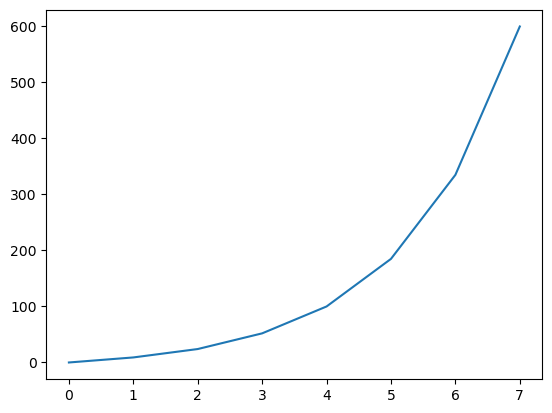

In [20]:
from animation_tools import generate_ids

cycles = 8
ids = generate_ids(0, 100, 600, cycles)  # 选取将在视频中展示的关键的代。因为初始进化快最终进化慢，后面间隔逐渐扩大
plt.plot(ids)
ids

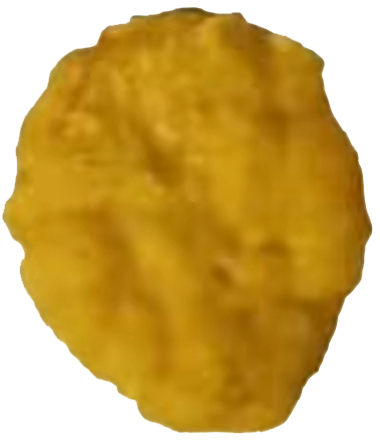

In [21]:
chicken_image = Image.open('../input_images/鸡块.png')
chicken_image = chicken_image.transpose(Image.FLIP_TOP_BOTTOM)
chicken_image

In [22]:
# 渲染多个不同形状的房间里相同形状沙发的运动

from tqdm.notebook import tqdm
import os
from scipy.ndimage import zoom
from utils import test_forbidden_function, get_area
from animation_tools import draw_sofa, dilate, draw_pattern
from PIL import Image, ImageDraw, ImageFont
import time

resolution = (2560, 1440)
delta_x = -300  # 画面整体横向移动
origin = [None, resolution[1] // 2]  # 原点在屏幕中的位置，随着动画会改变
scale = 630  # 单位1对应多少像素
duration = 114  # 每个房间展示的时长
transition_duration = 21  # 切换房间（转场）用时
period = 86  # 沙发旋转一周用时
time_scale = 1.0
emit_every_frames = int((duration + transition_duration) * time_scale)

output_path = '../rendering_results/能让鸡块旋转一周的房间_2/'

background_boundary_thickness = 12
background_upsampling = 3
sofa_upsampling = 2
need_update_background = True

# 如果输出路径不存在，构建路径
if not os.path.exists(output_path):
    os.makedirs(output_path)

sofa_h = 1.005  # 大一点是为了避免渲染时出现缝隙

active_rooms = []

def add_new_room(frame):
    id = ids[frame // emit_every_frames]
    assert os.path.exists(f'{path}sofa_{id}.npy')

    image = chicken_image
    # print(frame)
    xs, ys, rotations = np.load(f'{path}sofa_{id}.npy')
    # print(frame)

    xs_inv = []
    ys_inv = []
    rotations_inv = -rotations
    for x, y, angle in zip(-xs, -ys, rotations_inv):
        rotation_matrix = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])
        x_inv, y_inv = rotation_matrix @ np.array([x, y])
        xs_inv.append(x_inv)
        ys_inv.append(y_inv)
    xs_inv = np.array(xs_inv)
    ys_inv = np.array(ys_inv)

    xs_inv = zoom(xs_inv, zoom=(int(period * time_scale) + 1) / len(xs_inv), order=1)[:-1]  # 插值到动画循环帧数
    ys_inv = zoom(ys_inv, zoom=(int(period * time_scale) + 1) / len(ys_inv), order=1)[:-1]
    rotations_inv = zoom(rotations_inv, zoom=(int(period * time_scale) + 1) / len(rotations_inv), order=1)[:-1]

    # 背景
    background = get_sofa(
        is_forbidden,
        xs, ys, rotations,
        resolution=resolution[0] * background_upsampling,
        sofa_w=resolution[0] / scale, sofa_h=resolution[1] / scale,
        center_x=np.mean(xs_inv),
        center_y=np.mean(ys_inv),
        trajectory_upsampling=401
    )
    # ti.reset()  # 释放显存（但有可能导致下次用taichi计算时内核崩溃）
    # ti.init(arch=ti.gpu)
    # area = np.sum(~background) / (scale * background_upsampling) ** 2
    area = get_area(
        is_forbidden,
        xs, ys, rotations,
        sofa_w=2, sofa_h=2,
        resolution=2048,
        trajectory_upsampling=401
    )
    area = 4 - area
    background = background.T[::-1]
    y = (background.shape[0] - np.argmin(np.all(background, axis=1)[::-1])) / background_upsampling  # 房间最下端位置
    background_dilate = 1 - dilate(1 - background, radius=background_boundary_thickness * background_upsampling)
    background = np.array((255 - background * 75) * (1 - np.logical_xor(background, background_dilate)), dtype=np.uint8)
    background = np.stack([background, background, background], axis=-1)
    background = Image.fromarray(background)
    background = background.resize((background.width // background_upsampling, background.height // background_upsampling))
    draw = ImageDraw.Draw(background)
    text = f"#{id * 100}   S = {area:.4f}"
    font = ImageFont.truetype("simhei.ttf", 75)
    text_length = draw.textlength(text, font=font)
    draw.text((resolution[0] // 2 - text_length // 2, min(y + 50, resolution[1] - 100)), text, fill=(0, 0, 0), font=font)

    xs_inv -= np.mean(xs_inv)
    ys_inv -= np.mean(ys_inv)
    xs_inv += frame // emit_every_frames * resolution[0] / scale

    active_rooms.append({
        'cycle': frame // emit_every_frames,
        'sofa': image,  # 虽然每个房间的沙发形状相同，但为了好看绘制不同花纹，所以每个有独立的图片
        'background': background,
        'center': [np.mean(xs_inv) + frame // emit_every_frames * resolution[0], np.mean(ys_inv)],
        'xs': xs,
        'ys': ys,
        'rotations': rotations,
        'xs_inv': xs_inv,
        'ys_inv': ys_inv,
        'rotations_inv': rotations_inv
    })

add_new_room(0)
for frame in tqdm(range(emit_every_frames * cycles + 100)):
    cycle = frame // emit_every_frames
    frame_in_cycle = frame % emit_every_frames
    if frame_in_cycle == 0 or frame_in_cycle > duration * time_scale:
        if frame_in_cycle == 0:  # 刚转场完毕
            if cycle < cycles:
                origin[0] = resolution[0] * (0.5 - cycle) + delta_x
                while active_rooms[0]['cycle'] < cycle:
                    del active_rooms[0]  # 移除已经离开画面的房间
                need_update_background = True
        else:  # 正在转场
            if cycle < cycles - 1:
                if active_rooms[-1]['cycle'] <= cycle:  # 需要加入新的沙发
                    add_new_room((cycle + 1) * emit_every_frames)
                origin[0] = resolution[0] * (0.5 - cycle - (1 - np.cos((frame_in_cycle - duration * time_scale) / (transition_duration * time_scale) * np.pi)) / 2) + delta_x  # 转场
                need_update_background = True  # 转场时每帧都要重新渲染背景

    # 绘制背景
    rendering_target = Image.new('RGB', resolution, (180, 180, 180))
    # draw = ImageDraw.Draw(image)
    for room in active_rooms:
        rendering_target.paste(room['background'], (round(resolution[0] * (-0.5 + room['cycle']) + origin[0]), 0))  # 将背景绘制到画布中

    # 绘制沙发
    for room in active_rooms:
        draw_sofa(
            rendering_target,
            origin, scale,
            room['sofa'],
            room['xs_inv'], room['ys_inv'], room['rotations_inv'],
            frame % int(period * time_scale),
            sofa_h=sofa_h,
        )

    rendering_target.save(f"{output_path}{frame}.png", compress_level=6)

    # if frame > 95:
    #     break
    # break
# rendering_target

  0%|          | 0/1180 [00:00<?, ?it/s]